Loading model from best_model_50.pth...

--- Running Visual Sanity Check ---


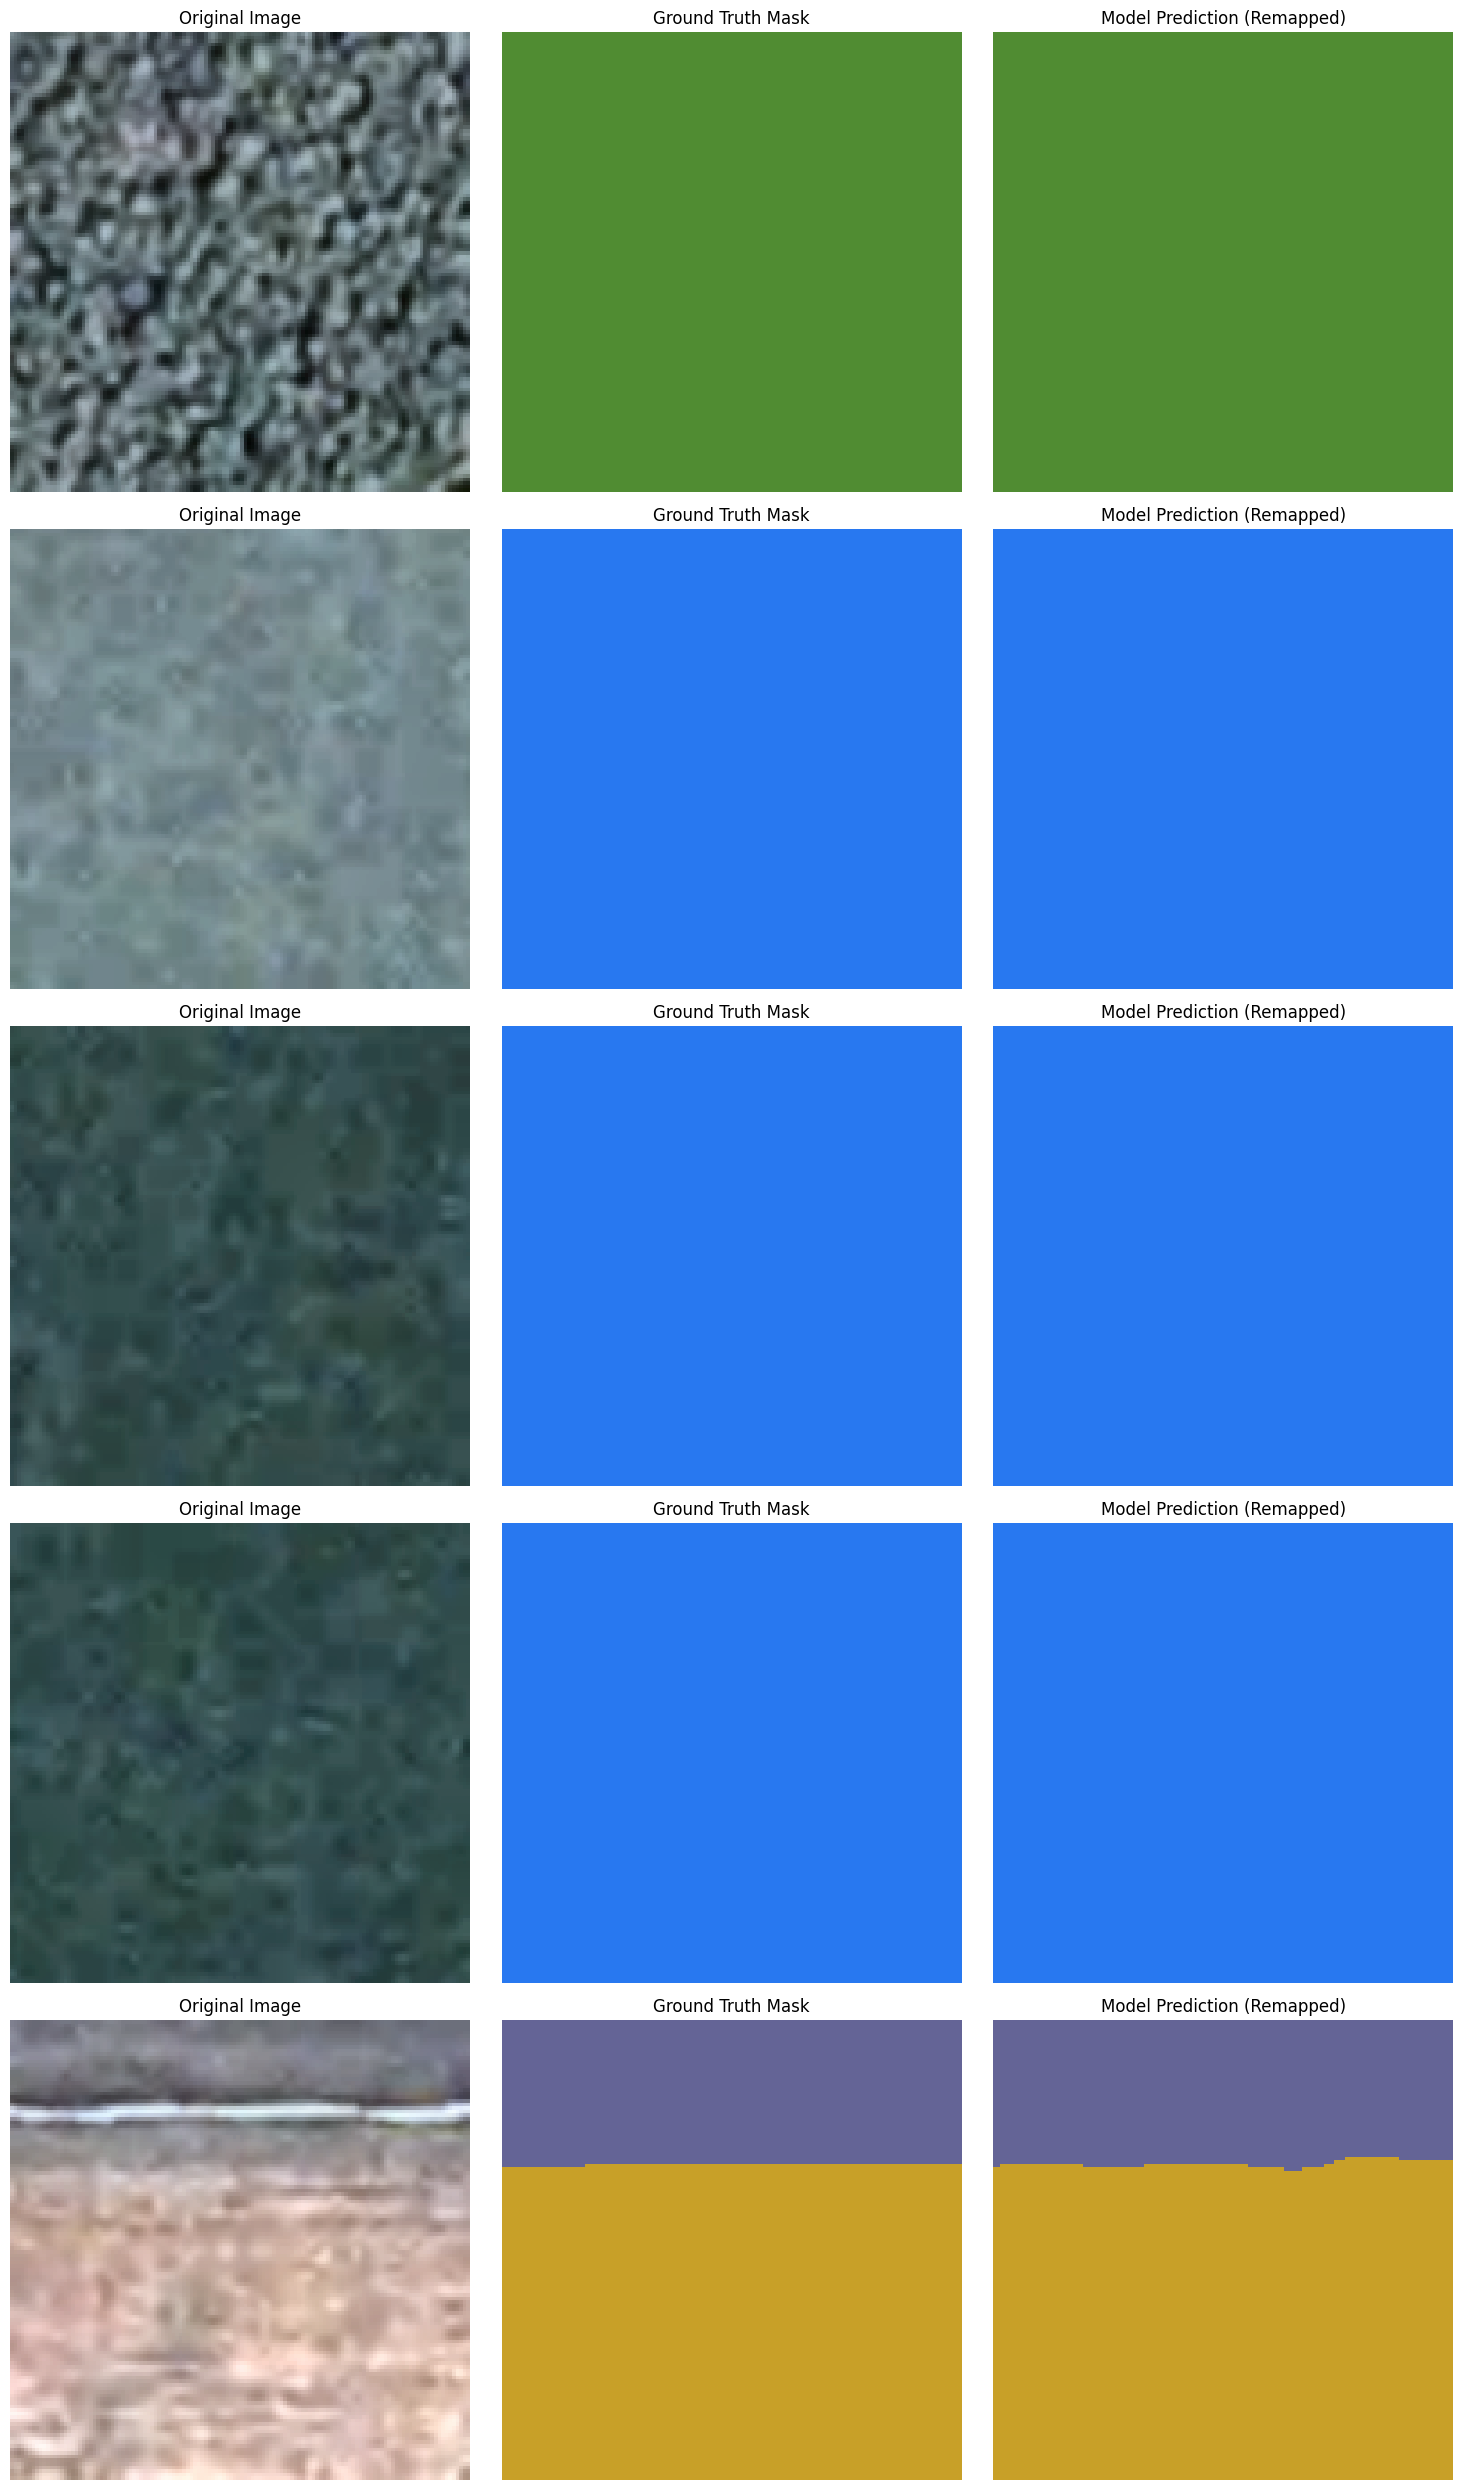


--- Starting Full Evaluation on Test Set ---


Testing:   0%|          | 0/56 [00:00<?, ?it/s]c:\Users\veerk\OneDrive\Desktop\DIP Project\dip\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Testing: 100%|██████████| 56/56 [00:43<00:00,  1.30it/s]



Inference complete. Evaluating 891 images.

--- Generating Evaluation Results ---


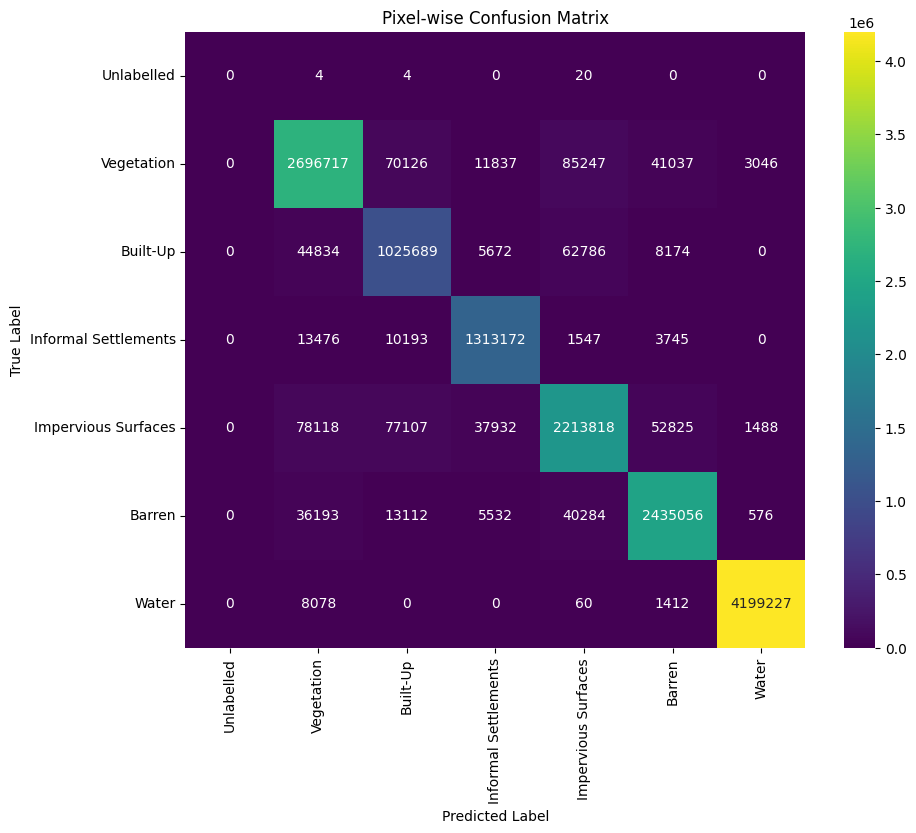

Generated: Confusion Matrix

--- Overall Performance Metrics (Macro Average on Relevant Classes) ---
Overall Pixel Accuracy: 0.9511
Mean IoU (mIoU):       0.8903
Mean Precision:        0.9380
Mean Recall:           0.9432
Mean F1-Score:         0.9405

--- Class-wise Performance Metrics ---
               Class    IoU  Precision  Recall  F1-Score
          Unlabelled 0.0000     0.0000  0.0000    0.0000
          Vegetation 0.8731     0.9372  0.9273    0.9322
            Built-Up 0.7784     0.8574  0.8941    0.8754
Informal Settlements 0.9359     0.9556  0.9784    0.9669
 Impervious Surfaces 0.8350     0.9210  0.8995    0.9101
              Barren 0.9231     0.9578  0.9622    0.9600
               Water 0.9965     0.9988  0.9977    0.9983


In [1]:
# results.py (Corrected for Class Remapping)

import torch
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2

# Import the updated utility functions
from data_utils_new import SegmentationDataset, CLASS_RGB_VALUES
from model_utils_new import get_model
from analyse_utils_new import plot_results

# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
IMAGE_SIZE = 128
NUM_CLASSES = 7

# IMPORTANT: Use the actual filename of your trained model.
# It might be "best_model_10.pth" or "best_model_50.pth".
MODEL_PATH = "best_model_50.pth" 

# --- Data Paths ---
BASE_PATH = r'..\Dataset\Prepared_dataset'
TEST_IMG_DIR = os.path.join(BASE_PATH, "test", "images")
TEST_MASK_DIR = os.path.join(BASE_PATH, "test", "masks")


# ------------------------- CORE FIX: CLASS REMAPPING -------------------------
# This array translates the model's output indices to match the ground truth indices.
# The model was trained with one class order, but evaluation uses a different one.
# This remaps the predicted index to the correct one for accurate comparison.
#
# Training Order         -> Evaluation Order
# -----------------------------------------------------
# 0: Informal Settlements -> 3: Informal Settlements
# 1: Built-Up            -> 2: Built-Up
# 2: Impervious Surfaces  -> 4: Impervious Surfaces
# 3: Vegetation          -> 1: Vegetation
# 4: Barren              -> 5: Barren
# 5: Water               -> 6: Water
# 6: Unlabelled          -> 0: Unlabelled
#
# The array is indexed by the trained model's output. For example, if the model
# predicts index 0, REMAP_ARRAY[0] gives 3, the correct index for evaluation.
REMAP_ARRAY = np.array([3, 2, 4, 1, 5, 6, 0], dtype=np.uint8)
# ---------------------------------------------------------------------------


# --- Transforms for Testing (Preprocessing only) ---
test_transform = A.Compose([
    A.Resize(height=IMAGE_SIZE, width=IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

def class_indices_to_rgb(mask, palette):
    """Converts a mask of class indices to an RGB image."""
    rgb_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_idx, color in enumerate(palette):
        rgb_mask[mask == class_idx] = color
    return rgb_mask

def visual_sanity_check(model, test_dataset, device, remap_array, num_samples=5):
    """
    Displays original images, ground truth masks, and remapped model predictions.
    """
    print("\n--- Running Visual Sanity Check ---")
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    model.eval()
    indices = np.random.choice(len(test_dataset), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, num_samples * 5))
    if num_samples == 1: axes = np.array([axes]) # Ensure axes is iterable

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image_tensor, mask_tensor = test_dataset[idx]
            
            # --- Get Model Prediction ---
            input_tensor = image_tensor.unsqueeze(0).to(device)
            logits = model(input_tensor)
            prediction_raw = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

            # --- FIX: Apply the remapping to the raw prediction ---
            prediction_remapped = remap_array[prediction_raw]

            # --- Prepare Images for Plotting ---
            image_display = image_tensor.permute(1, 2, 0).numpy()
            image_display = (image_display * std) + mean
            image_display = np.clip(image_display, 0, 1)

            gt_mask_rgb = class_indices_to_rgb(mask_tensor.squeeze().numpy(), CLASS_RGB_VALUES)
            pred_mask_rgb = class_indices_to_rgb(prediction_remapped, CLASS_RGB_VALUES)
            
            axes[i, 0].imshow(image_display)
            axes[i, 0].set_title("Original Image")
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(gt_mask_rgb)
            axes[i, 1].set_title("Ground Truth Mask")
            axes[i, 1].axis('off')

            axes[i, 2].imshow(pred_mask_rgb)
            axes[i, 2].set_title("Model Prediction (Remapped)")
            axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

def evaluate_model():
    if not os.path.exists(MODEL_PATH):
        print(f"ERROR: Model checkpoint '{MODEL_PATH}' not found. Please check the filename.")
        return
    if not os.path.exists(TEST_IMG_DIR):
        print(f"ERROR: Test data path not found: {TEST_IMG_DIR}")
        return

    print(f"Loading model from {MODEL_PATH}...")
    model = get_model(DEVICE, classes=NUM_CLASSES)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    
    test_dataset = SegmentationDataset(TEST_IMG_DIR, TEST_MASK_DIR, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    
    # --- RUN THE VISUAL CHECK FIRST (pass the remap array) ---
    visual_sanity_check(model, test_dataset, DEVICE, remap_array=REMAP_ARRAY)
    
    print("\n--- Starting Full Evaluation on Test Set ---")
    all_predictions = []
    all_ground_truths = []
    
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Testing"):
            images = images.to(DEVICE)
            logits = model(images)
            predictions_raw = torch.argmax(logits, dim=1).cpu().numpy()
            
            # --- FIX: Remap the entire batch of predictions ---
            predictions_remapped = REMAP_ARRAY[predictions_raw]
            
            all_predictions.append(predictions_remapped)
            all_ground_truths.append(masks.squeeze().numpy())

    final_predictions = np.concatenate(all_predictions, axis=0)
    final_ground_truths = np.concatenate(all_ground_truths, axis=0)
    
    print(f"\nInference complete. Evaluating {len(final_predictions)} images.")
    
    # plot_results now receives correctly aligned predictions and ground truths
    plot_results(final_predictions, final_ground_truths)

if __name__ == '__main__':
    evaluate_model()